In [1]:
import pandas as pd , numpy as np, seaborn as sns , matplotlib.pyplot as plt, missingno as msno

In [2]:
data = pd.read_csv("customer_churn.csv")

In [3]:
df = data.copy(deep=True)

In [4]:
df.shape

(7043, 23)

In [5]:
df.describe()

,SeniorCitizen,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,0.162147,64.761692,2378.061540
std,0.368612,30.090047,8240.658842
min,0.000000,18.250000,18.800000
25%,0.000000,35.500000,401.762500
50%,0.000000,70.350000,1397.950000
75%,0.000000,89.850000,3796.912500
max,1.000000,118.750000,666666.000000


In [6]:
df.describe(include='O')

,CustomerID,Gender,Partner,Dependents,BillingType,AccountClosed,CustomerStartDate,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,73,2,3,3,3,3,3,3,3,3,4,2,5,2
top,7590-VHVEG,Male,No,No,Paperless,No,2019-12-02,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,4171,4824,613,6361,3390,3096,3498,3088,3095,3473,2810,2785,3815,4171,2360,5174


In [7]:
def missing_value_summary(df):
    Missing_value_col_summary = (df.isnull().sum().reset_index().rename(columns={'index': 'column', 0: 'missing_count'}))
    Missing_value_col_summary['missing_percent'] = (Missing_value_col_summary['missing_count'] / len(df) * 100)

    Missing_value_col_summary = Missing_value_col_summary[Missing_value_col_summary["missing_count"] > 0]
    Missing_value_col_summary.sort_values(by="missing_percent", ascending=False, inplace=True)
    Missing_value_col_summary.reset_index(drop=True, inplace=True)
    return Missing_value_col_summary

In [8]:
missing_val_table = missing_value_summary(df)
missing_val_table

,column,missing_count,missing_percent
0,TotalCharges,11,0.156183


In [9]:
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
def drop_missing_values(df, axis=0, subset=None):
    return df.dropna(axis=axis, subset=subset)

In [11]:
df = drop_missing_values(df, axis=0, subset=None)
df

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,BillingType,AccountClosed,CustomerStartDate,PhoneService,MultipleLines,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,Paperless,No,2019-12-02,No,No phone service,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Paper,No,2017-03-17,Yes,No,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Paperless,Yes,2019-11-02,Yes,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,Paper,No,2016-04-21,No,No phone service,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Paperless,Yes,2019-11-02,Yes,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Paperless,No,2018-01-11,Yes,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Paperless,No,2014-02-01,Yes,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,Paperless,No,2019-02-05,No,No phone service,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Paperless,Yes,2019-09-03,Yes,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# Univartiate analysis 

In [13]:
def univariate_analysis(df, col):
    data = df[col].dropna()

    # Numeric variables
    if pd.api.types.is_numeric_dtype(data):
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        # Histogram
        ax[0].hist(data)
        ax[0].set_title(f"Histogram of {col}")

        # Boxplot
        ax[1].boxplot(data, vert=True)
        ax[1].set_title(f"Boxplot of {col}")

        plt.tight_layout()
        plt.show()

        print(data.describe())

    # Categorical variables
    else:
        vc = data.value_counts()

        plt.figure(figsize=(8, 4))
        vc.plot(kind='bar')
        plt.title(f"Bar Plot of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

        print(vc)


In [14]:
df.columns.to_list()

['CustomerID',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'BillingType',
 'AccountClosed',
 'CustomerStartDate',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

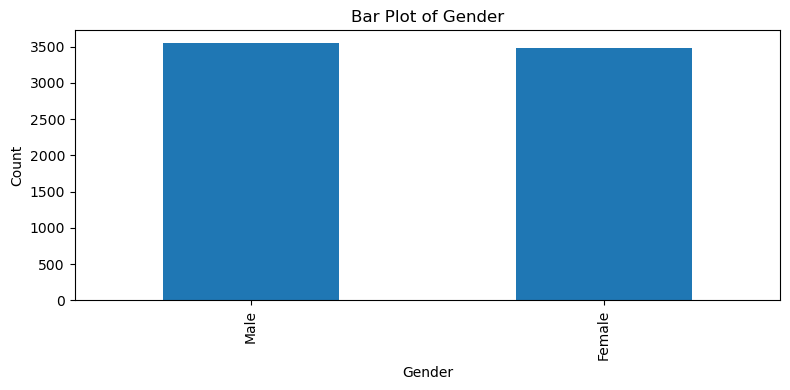

Gender
Male      3549
Female    3483
Name: count, dtype: int64


In [15]:
 univariate_analysis(df,'Gender')

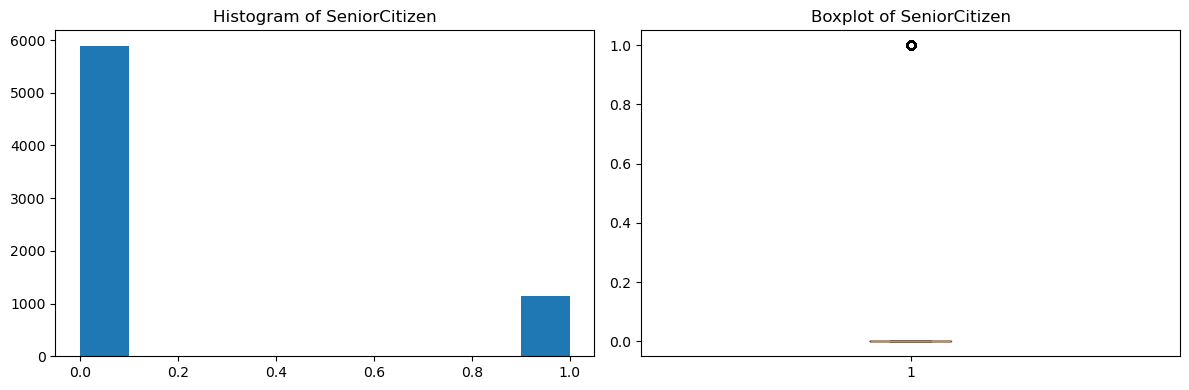

count    7032.000000
mean        0.162400
std         0.368844
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64


In [16]:
univariate_analysis(df,'SeniorCitizen')

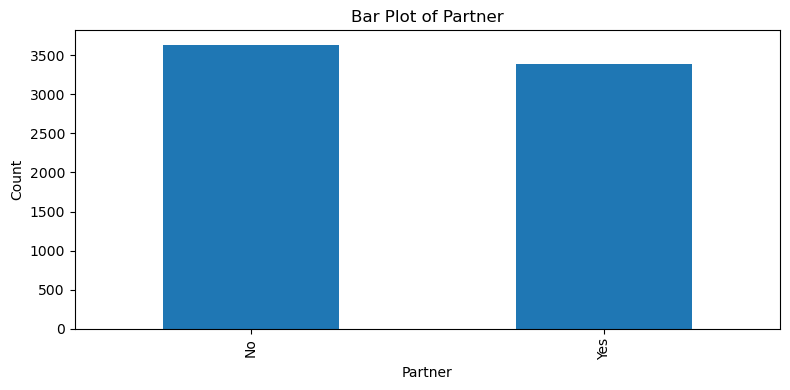

Partner
No     3639
Yes    3393
Name: count, dtype: int64


In [17]:
 univariate_analysis(df,'Partner')

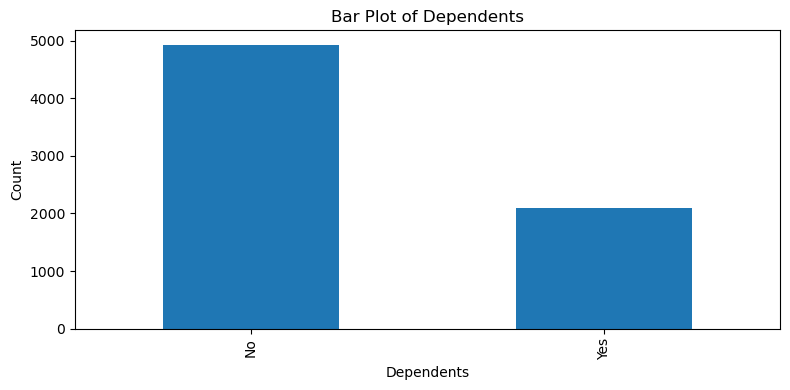

Dependents
No     4933
Yes    2099
Name: count, dtype: int64


In [18]:
 univariate_analysis(df,'Dependents')

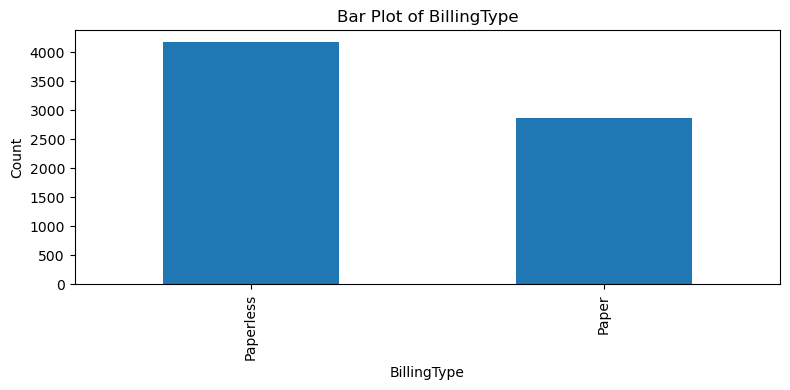

BillingType
Paperless    4168
Paper        2864
Name: count, dtype: int64


In [19]:
 univariate_analysis(df,'BillingType')

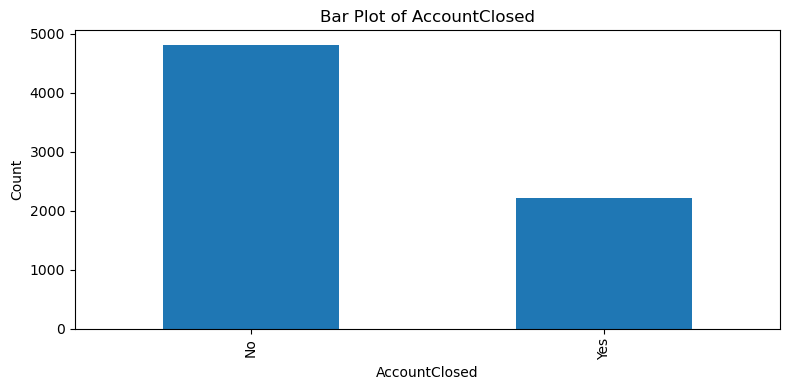

AccountClosed
No     4814
Yes    2218
Name: count, dtype: int64


In [20]:
 univariate_analysis(df,'AccountClosed')

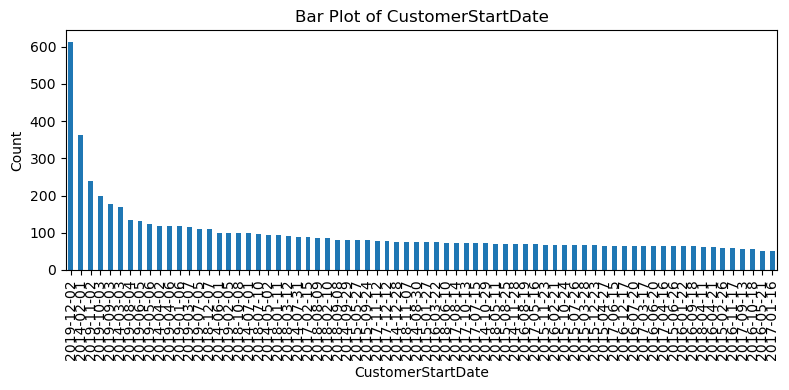

CustomerStartDate
2019-12-02    613
2014-02-01    362
2019-11-02    238
2019-10-03    200
2019-09-03    176
             ... 
2016-11-17     59
2017-09-13     57
2016-10-18     56
2016-05-21     51
2017-01-16     50
Name: count, Length: 72, dtype: int64


In [21]:
 univariate_analysis(df,'CustomerStartDate')

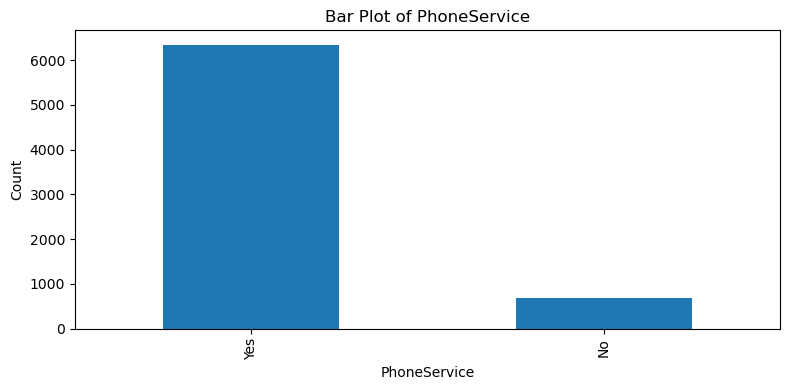

PhoneService
Yes    6352
No      680
Name: count, dtype: int64


In [22]:
 univariate_analysis(df,'PhoneService')

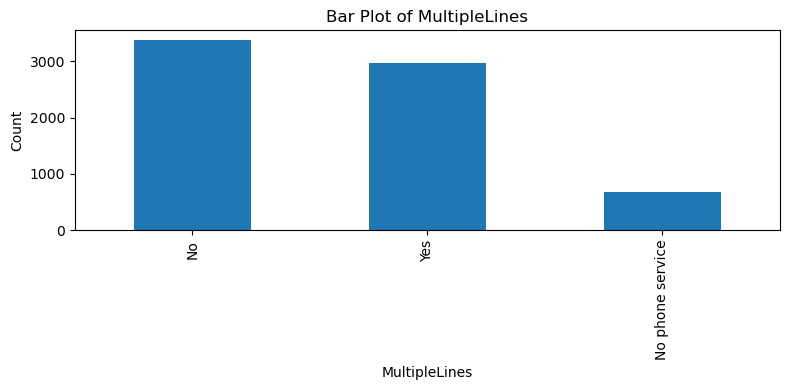

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64


In [23]:
 univariate_analysis(df,'MultipleLines')

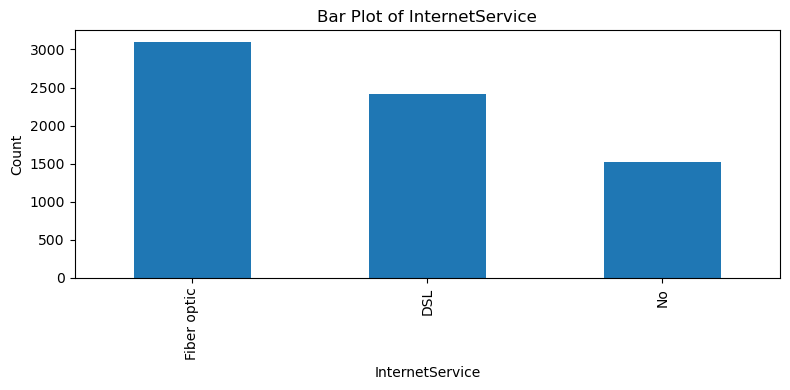

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64


In [24]:
 univariate_analysis(df,'InternetService')

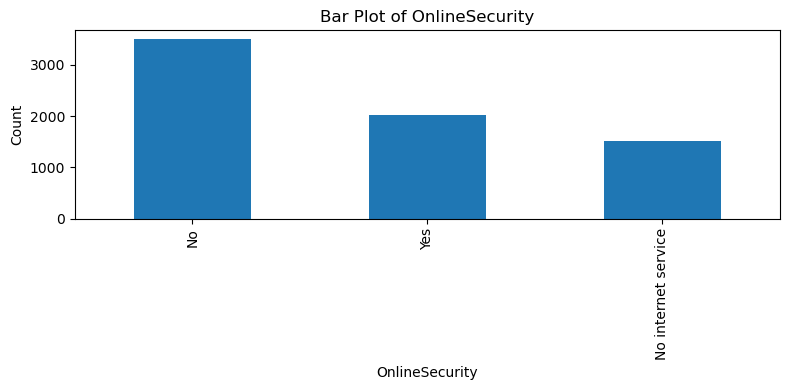

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64


In [25]:
 univariate_analysis(df,'OnlineSecurity')

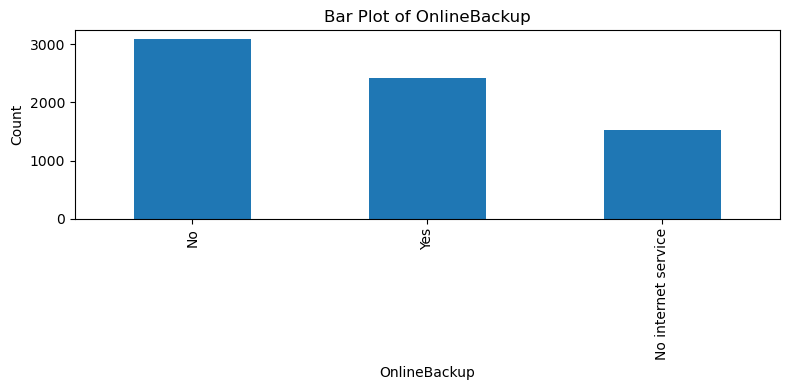

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64


In [26]:
 univariate_analysis(df,'OnlineBackup')

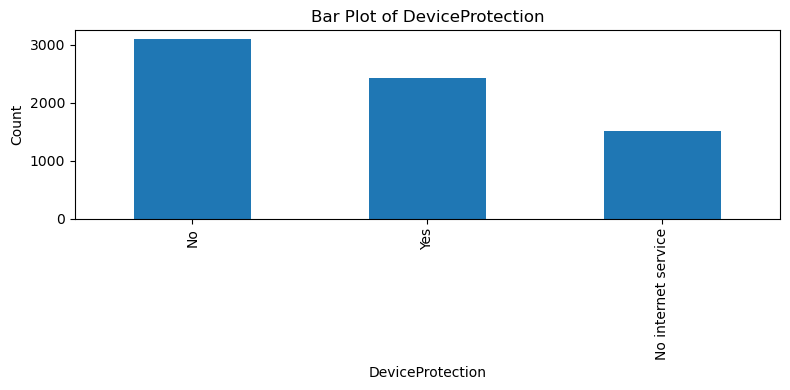

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64


In [27]:
 univariate_analysis(df,'DeviceProtection')

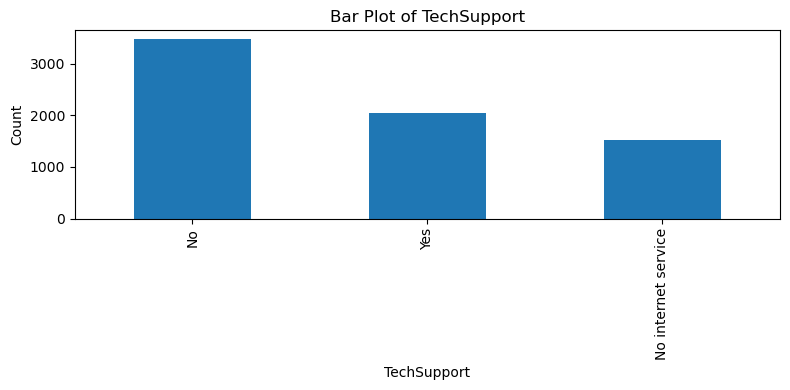

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64


In [28]:
 univariate_analysis(df,'TechSupport')

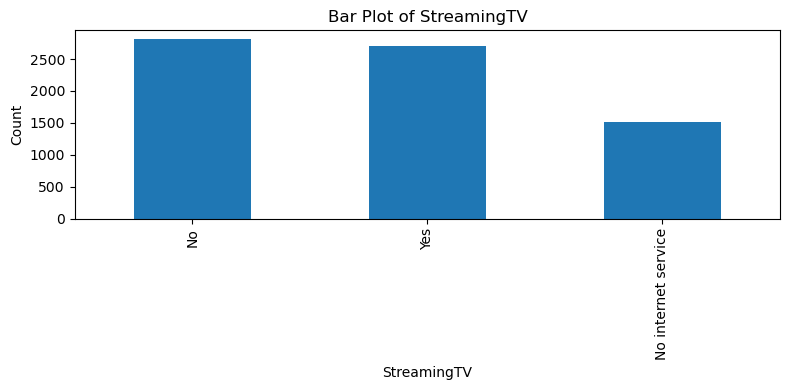

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64


In [29]:
 univariate_analysis(df,'StreamingTV')

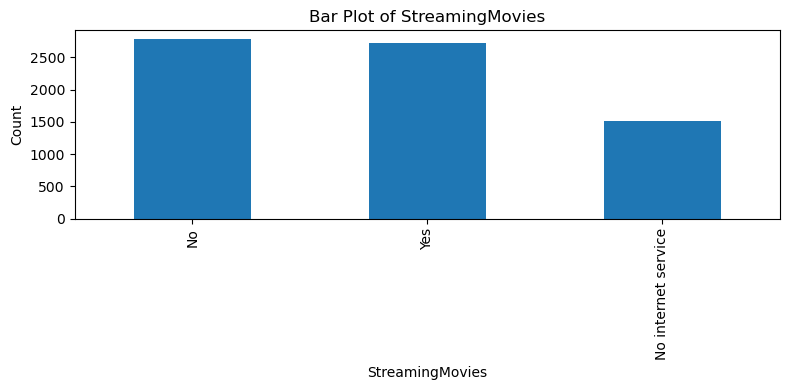

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64


In [30]:
 univariate_analysis(df,'StreamingMovies')

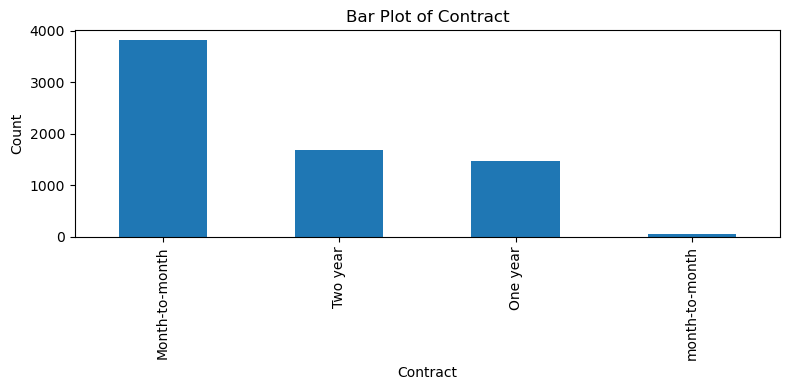

Contract
Month-to-month    3815
Two year          1685
One year          1472
month-to-month      60
Name: count, dtype: int64


In [31]:
 univariate_analysis(df,'Contract')

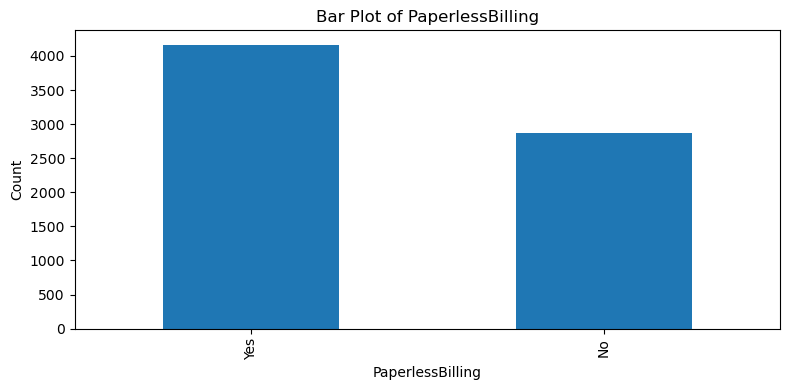

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64


In [32]:
 univariate_analysis(df,'PaperlessBilling')

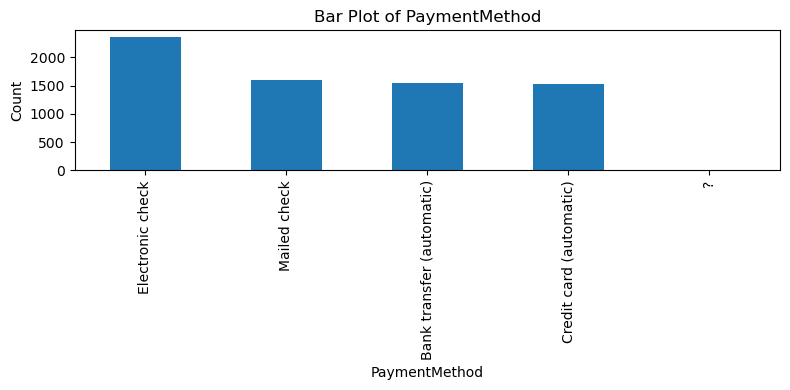

PaymentMethod
Electronic check             2360
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
?                               5
Name: count, dtype: int64


In [33]:
 univariate_analysis(df,'PaymentMethod')

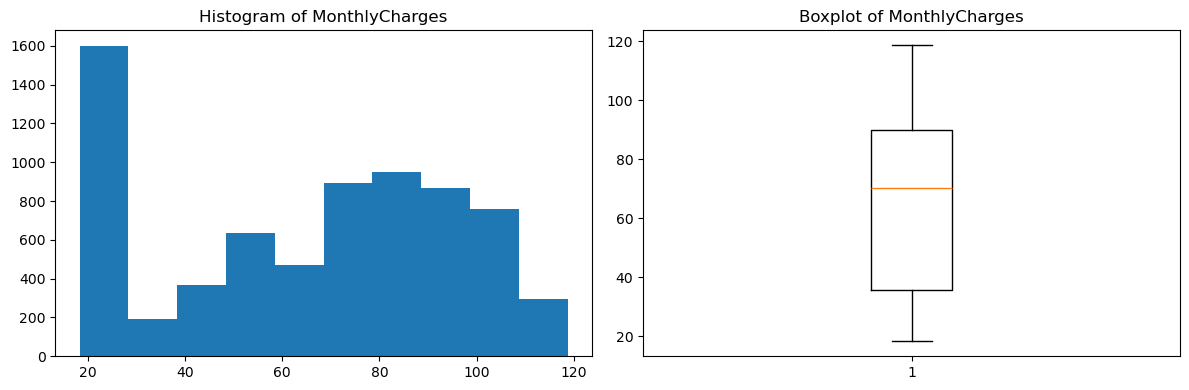

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64


In [34]:
 univariate_analysis(df,'MonthlyCharges')

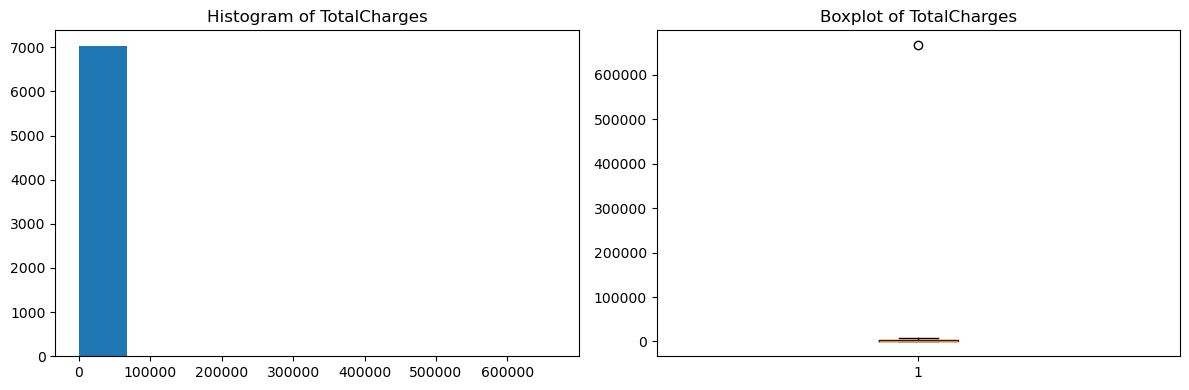

count      7032.000000
mean       2378.061540
std        8240.658842
min          18.800000
25%         401.762500
50%        1397.950000
75%        3796.912500
max      666666.000000
Name: TotalCharges, dtype: float64


In [35]:
 univariate_analysis(df,'TotalCharges')

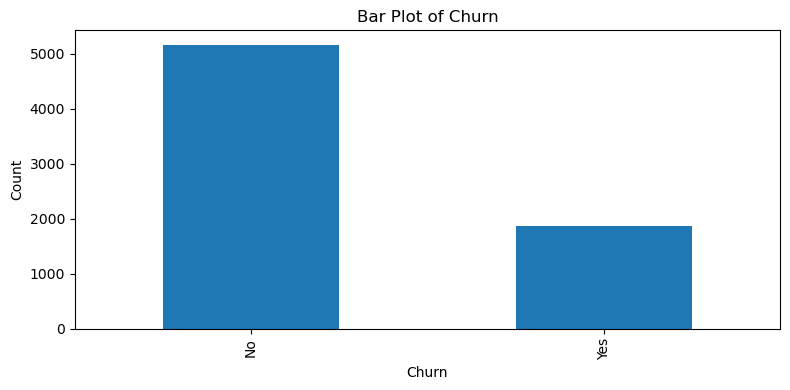

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [36]:
 univariate_analysis(df,'Churn')

In [37]:
def detect_outliers(df):
    numeric_cols = df.select_dtypes(include='number').columns
    outlier_cols = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if df[(df[col] < lower) | (df[col] > upper)].shape[0] > 0:
            outlier_cols.append(col)

    return outlier_cols

In [38]:
outlier_columns = detect_outliers(df)
outlier_columns

['SeniorCitizen', 'TotalCharges']

In [39]:
def remove_outliers(df, cols):
    df_clean = df.copy()

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

In [40]:
df_clean = remove_outliers(df, outlier_columns)
df=df_clean

In [42]:
df

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,BillingType,AccountClosed,CustomerStartDate,PhoneService,MultipleLines,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,Paperless,No,2019-12-02,No,No phone service,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Paper,No,2017-03-17,Yes,No,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Paperless,Yes,2019-11-02,Yes,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,Paper,No,2016-04-21,No,No phone service,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Paperless,Yes,2019-11-02,Yes,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,2569-WGERO,Female,0,No,No,Paperless,No,2014-02-01,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,6840-RESVB,Male,0,Yes,Yes,Paperless,No,2018-01-11,Yes,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Paperless,No,2014-02-01,Yes,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,Paperless,No,2019-02-05,No,No phone service,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [43]:
def correlation_heatmap(df):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix Heatmap")
    plt.show()

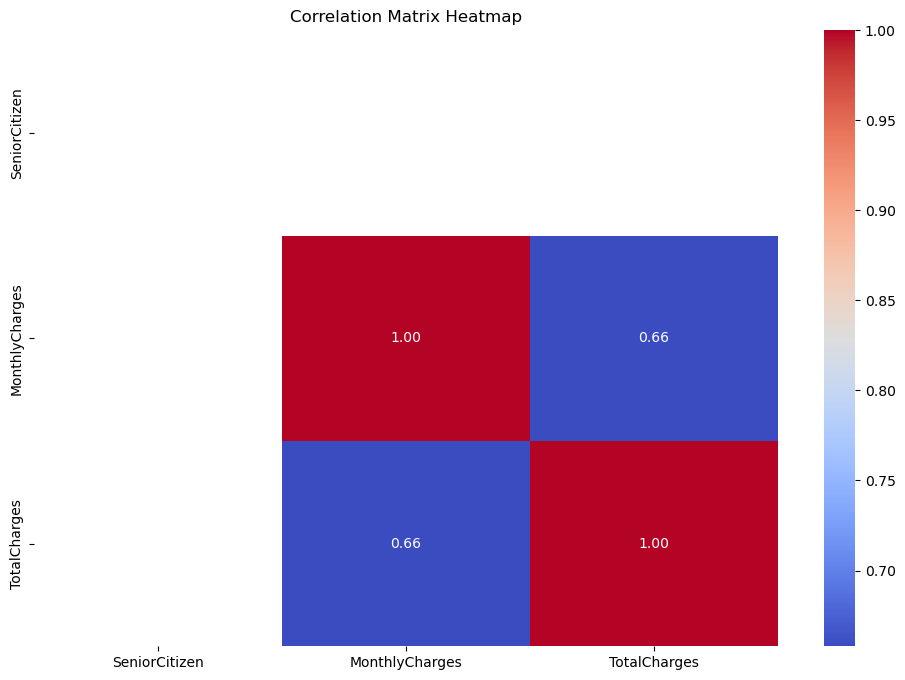

In [44]:
correlation_heatmap(df)

In [45]:
def pairwise_plot_all(df):
    
    # convert categoricals to numeric codes
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype('category').cat.codes
    
    sns.pairplot(df)
    plt.show()

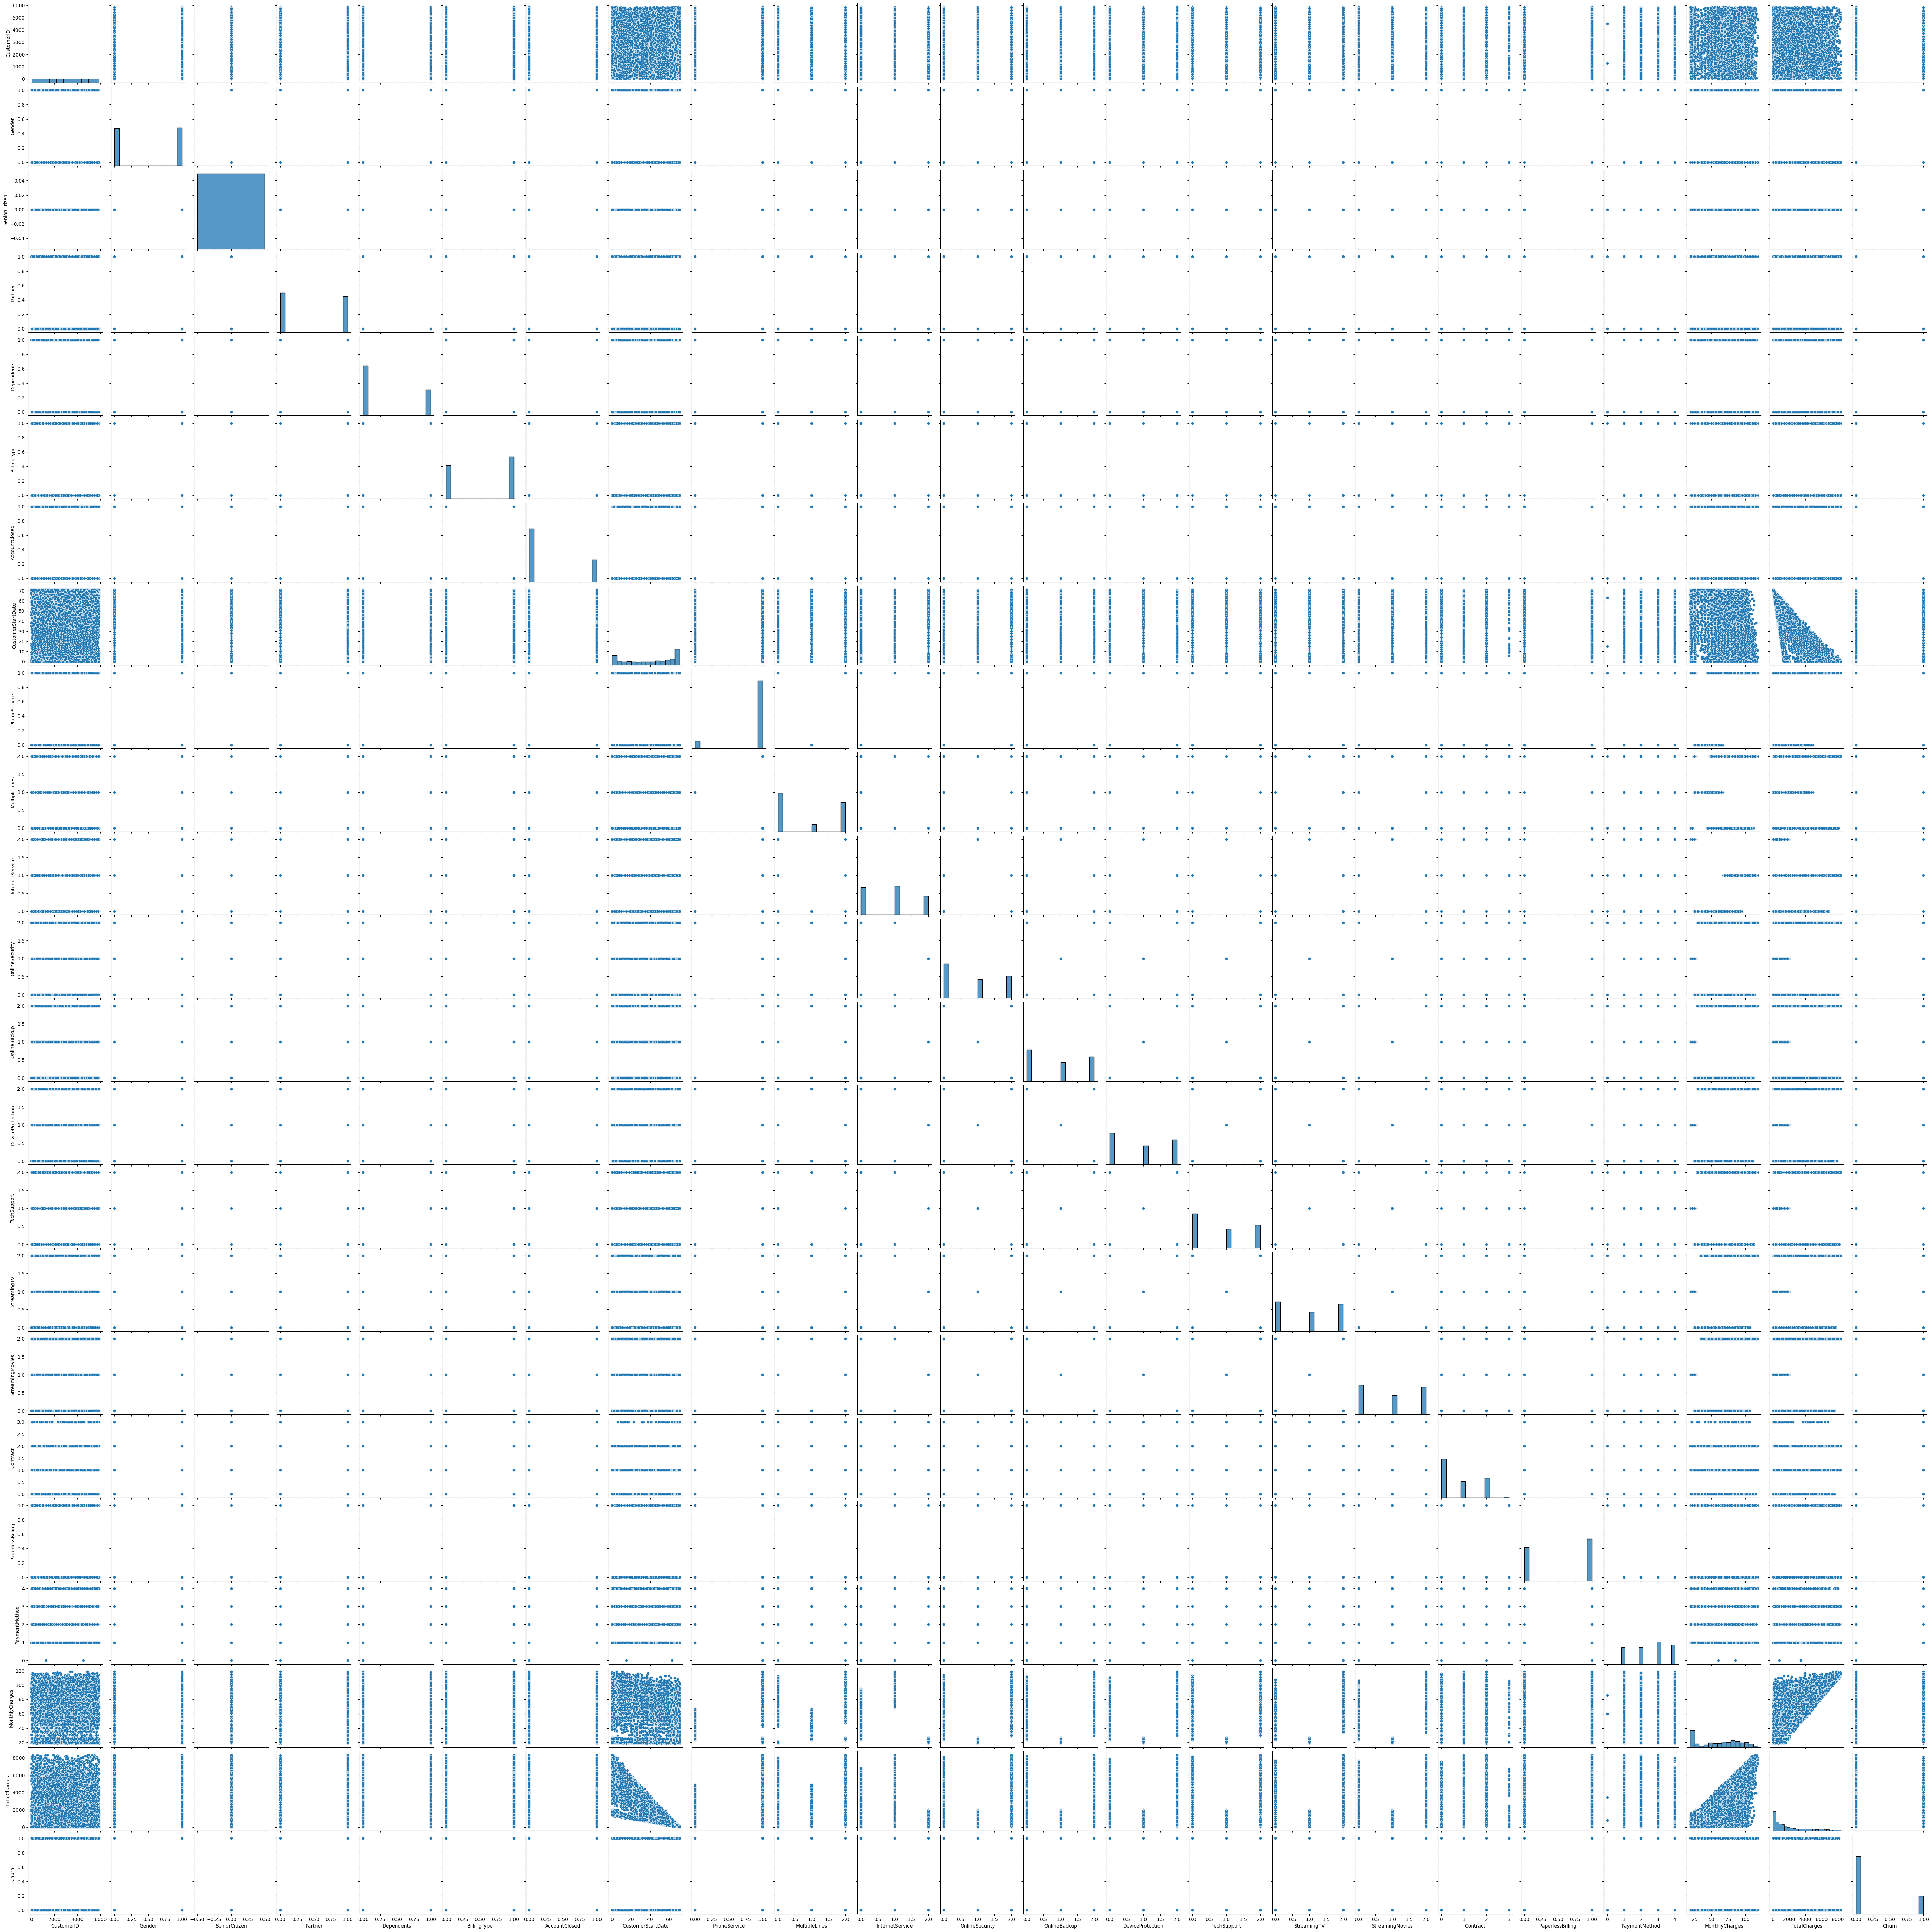

In [46]:
pairwise_plot_all(df)

In [47]:
df.columns.to_list()


['CustomerID',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'BillingType',
 'AccountClosed',
 'CustomerStartDate',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

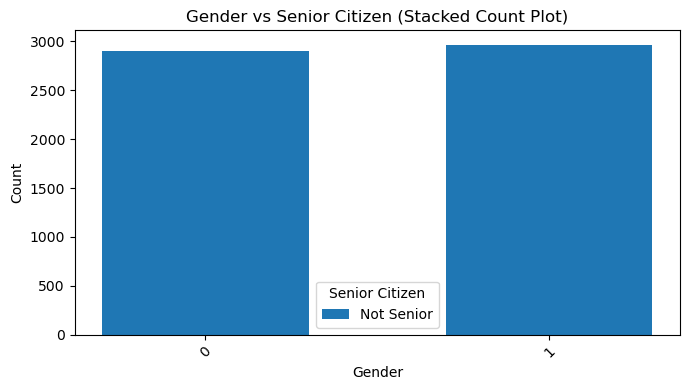

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df["SeniorCitizenLabel"] = df["SeniorCitizen"].map( {0: "Not Senior", 1: "Senior"})

counts = (
    df.groupby(["Gender", "SeniorCitizenLabel"])
      .size()
      .unstack(fill_value=0)
)

# Extract categories dynamically
genders = counts.index.tolist()
categories = counts.columns.tolist()

x = np.arange(len(genders))
width = 0.6

fig, ax = plt.subplots(figsize=(7, 4))

# bottom tracker for stacking
bottom = np.zeros(len(genders))

for cat in categories:
    ax.bar(x, counts[cat].values, width, bottom=bottom, label=cat)
    bottom += counts[cat].values

ax.set_title("Gender vs Senior Citizen (Stacked Count Plot)")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(genders, rotation=45)
ax.legend(title="Senior Citizen")

plt.tight_layout()
plt.show()

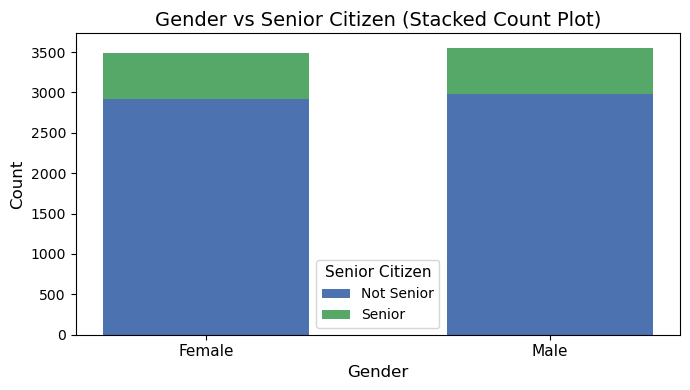

In [57]:
df_plot["SeniorCitizenLabel"] = df_plot["SeniorCitizen"].map({0: "Not Senior", 1: "Senior"})

counts = (
    df_plot.groupby(["Gender", "SeniorCitizenLabel"])
           .size()
           .unstack(fill_value=0)
)

genders = counts.index.tolist()
categories = counts.columns.tolist()

x = np.arange(len(genders))
width = 0.6
bottom = np.zeros(len(genders))

# business-friendly colours
colors = {
    "Not Senior": "#4C72B0",   # professional blue
    "Senior": "#55A868"        # green
}

fig, ax = plt.subplots(figsize=(7, 4))

for cat in categories:
    ax.bar(x, counts[cat].values, width, bottom=bottom,
           label=cat, color=colors.get(cat, "#999999"))
    bottom += counts[cat].values

ax.set_title("Gender vs Senior Citizen (Stacked Count Plot)", fontsize=14)
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(genders, rotation=0, fontsize=11)

ax.legend(title="Senior Citizen", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()
